## Homework 2 — CIFAR-10 Image Classification from Scratch

## **Learning Objectives**

By completing this assignment, students will be able to:

1.   Build a convolutional neural network from scratch for image classification
2.   Understand CIFAR-10 data preprocessing and augmentation
3.   Implement training, validation, and evaluation loops in PyTorch
4.   Analyze model performance using accuracy curves and confusion matrices
5.   Reason about architectural and optimization choices

## **Constraints (Very Important)**

**You may NOT:**

*   Use pretrained models (e.g., ResNet, VGG, EfficientNet)
*   Import torchvision models
Copy architectures directly from tutorials

**You may:**

*   Use PyTorch, torchvision datasets, and standard layers
*   Design your own CNN architecture
*   Tune hyperparameters

## **About CIFAR-10 Dataset**
This assignment uses the CIFAR-10 dataset:

*   60,000 RGB images (32×32)
*   10 classes
*   50,000 training images and 10,000 test images

**Classes:**
airplane, automobile, bird, cat, deer,
dog, frog, horse, ship, truck


In [3]:
# Import (you can import others if needed)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


## **Data Pipeline: CIFAR-10 Dataset Preparation**

#### **Purpose:**
This section loads the CIFAR-10 dataset and prepares it for training and evaluation.
The data pipeline handles image preprocessing, normalization, optional data augmentation, and mini-batch loading using PyTorch DataLoader.
A proper data pipeline is critical for stable training and good generalization performance.

In [6]:
# Select device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Load CIFAR-10 training data without normalization (for statistics computation)
raw_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

raw_loader = DataLoader(
    raw_train_dataset,
    batch_size=256,
    shuffle=False
)


# Compute per-channel mean and standard deviation from training data
channel_sum = torch.zeros(3)
channel_sum_sq = torch.zeros(3)
num_pixels = 0

for images, _ in raw_loader:
    b, c, h, w = images.shape
    num_pixels += b * h * w

    channel_sum += images.sum(dim=(0, 2, 3))
    channel_sum_sq += (images ** 2).sum(dim=(0, 2, 3))

cifar10_mean = (channel_sum / num_pixels).tolist()
cifar10_std = (channel_sum_sq / num_pixels - torch.tensor(cifar10_mean) ** 2).sqrt().tolist()

print("CIFAR-10 mean:", cifar10_mean)
print("CIFAR-10 std:", cifar10_std)


# Training data transformations (with augmentation)
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std)
])


# Test data transformations (no augmentation)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std)
])


# Load CIFAR-10 datasets with final transforms
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)


# Create DataLoaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


# Class labels
class_names = train_dataset.classes
print("CIFAR-10 Classes:", class_names)


Using device: cpu
CIFAR-10 mean: [0.4913996458053589, 0.48215845227241516, 0.4465310275554657]
CIFAR-10 std: [0.2470323145389557, 0.24348507821559906, 0.26158758997917175]
CIFAR-10 Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## **CNN Architecture: Designing a CIFAR-10 Classifier**

**Purpose:**

This section defines a custom convolutional neural network (CNN) for CIFAR-10 classification. The model learns hierarchical features from images using convolution layers and then maps those learned features to 10 output classes using fully connected layers. The design includes multiple convolution blocks, ReLU nonlinearities, and max pooling for downsampling.

In [7]:
# CNN model definition
class CIFAR10Net(nn.Module):
    def __init__(self):
        super().__init__()

        # First convolutional block
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional block
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third convolutional block
        self.conv5 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        # Input shape: (batch_size, 3, 32, 32)

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool2(x)

        x = F.relu(self.conv5(x))
        x = self.pool3(x)

        # Flatten feature maps
        x = x.view(x.size(0), -1)

        # Classification layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # output logits

        return x

# Instantiate the model and move it to the selected device
model = CIFAR10Net().to(device)
print(model)


CIFAR10Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


## **Training Methodology: Model Optimization and Learning**

**Purpose:**

This section defines how the network parameters are optimized using labeled training data. It specifies the loss function, optimizer, and the iterative training process used to update model weights based on prediction errors.

In [10]:
#Training Setup and Loop
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Number of training epochs
epochs = 20

# Containers for tracking performance
train_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):

    # Enable training mode
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Evaluation on test data
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_accuracy = correct / total
    test_accuracies.append(test_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Test Acc: {test_accuracy:.4f}"
    )


Epoch [1/20] Train Loss: 1.7102 Train Acc: 0.3689 Test Acc: 0.5026
Epoch [2/20] Train Loss: 1.3059 Train Acc: 0.5246 Test Acc: 0.6031
Epoch [3/20] Train Loss: 1.1012 Train Acc: 0.6068 Test Acc: 0.6625
Epoch [4/20] Train Loss: 0.9587 Train Acc: 0.6620 Test Acc: 0.7023
Epoch [5/20] Train Loss: 0.8636 Train Acc: 0.6974 Test Acc: 0.7398
Epoch [6/20] Train Loss: 0.7911 Train Acc: 0.7230 Test Acc: 0.7540
Epoch [7/20] Train Loss: 0.7434 Train Acc: 0.7415 Test Acc: 0.7707
Epoch [8/20] Train Loss: 0.7057 Train Acc: 0.7539 Test Acc: 0.7805
Epoch [9/20] Train Loss: 0.6697 Train Acc: 0.7677 Test Acc: 0.7779
Epoch [10/20] Train Loss: 0.6384 Train Acc: 0.7788 Test Acc: 0.7969
Epoch [11/20] Train Loss: 0.6106 Train Acc: 0.7879 Test Acc: 0.8039
Epoch [12/20] Train Loss: 0.5945 Train Acc: 0.7924 Test Acc: 0.8086
Epoch [13/20] Train Loss: 0.5845 Train Acc: 0.8002 Test Acc: 0.8049
Epoch [14/20] Train Loss: 0.5496 Train Acc: 0.8096 Test Acc: 0.8169
Epoch [15/20] Train Loss: 0.5383 Train Acc: 0.8128 Test A

# **Gradient Tracking**

In [16]:
grad_history = {"conv1": [], "conv3": [], "conv5": [], "fc1": []}

def grad_norm(param):
    return 0.0 if param.grad is None else param.grad.detach().norm(2).item()

model.train()

num_steps = 50
for step, (images, labels) in enumerate(train_loader):
    if step >= num_steps:
        break

    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()

    grad_history["conv1"].append(grad_norm(model.conv1.weight))
    grad_history["conv3"].append(grad_norm(model.conv3.weight))
    grad_history["conv5"].append(grad_norm(model.conv5.weight))
    grad_history["fc1"].append(grad_norm(model.fc1.weight))

    # Optional: comment out if you want zero weight updates during diagnostics
    optimizer.step()


## **Visualization: Gradient Flow and Learning Curves**



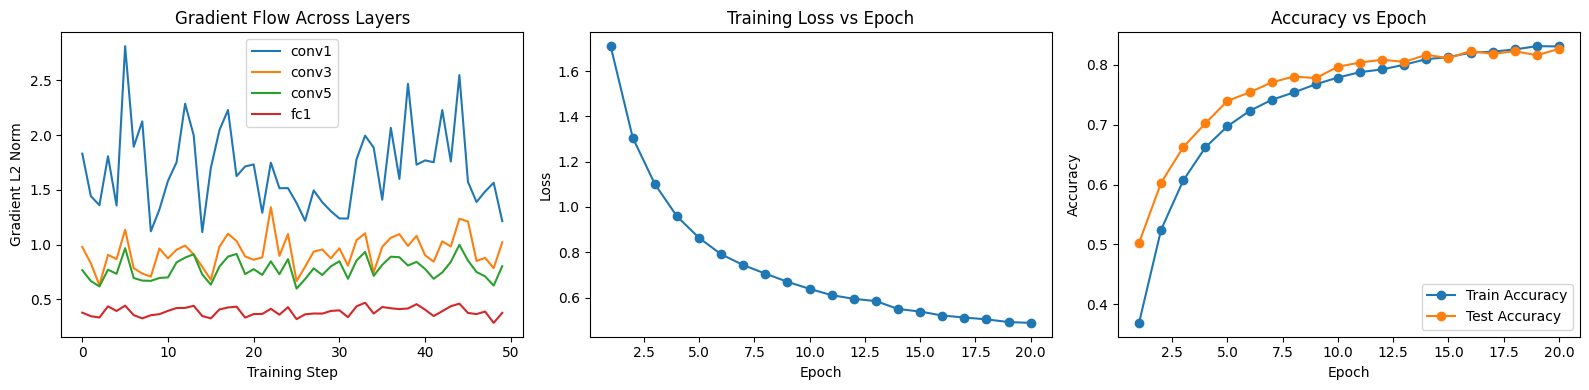

In [17]:
# Epoch axis
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(16, 4))

# Gradient flow across selected layers
plt.subplot(1, 3, 1)
plt.plot(grad_history["conv1"], label="conv1")
plt.plot(grad_history["conv3"], label="conv3")
plt.plot(grad_history["conv5"], label="conv5")
plt.plot(grad_history["fc1"], label="fc1")
plt.xlabel("Training Step")
plt.ylabel("Gradient L2 Norm")
plt.title("Gradient Flow Across Layers")
plt.legend()


# Training loss over epochs
plt.subplot(1, 3, 2)
plt.plot(epochs, train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")


# Training and test accuracy over epochs
plt.subplot(1, 3, 3)
plt.plot(epochs, train_accuracies, marker='o', label="Train Accuracy")
plt.plot(epochs, test_accuracies, marker='o', label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()

plt.tight_layout()
plt.show()


Figure  illustrates the gradient flow across selected convolutional and fully connected layers, as well as the training loss and accuracy trends. Gradient norms remain non-zero and stable across layers, indicating effective backpropagation without vanishing or exploding gradients. Training loss decreases smoothly with epochs, while both training and test accuracy increase consistently and remain closely aligned, demonstrating stable convergence and good generalization performance.

## **Confusion Matrix: Evaluating Class-Wise Performance**

**Purpose:**

Overall accuracy tells us how often the model is correct, but it does not show which classes are confused with each other.
A confusion matrix provides a detailed, class-by-class breakdown of predictions versus true labels.

**Generate Predictions on the Test Set**

In [18]:
from sklearn.metrics import confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())



Compute the Confusion Matrix

In [19]:
cm = confusion_matrix(all_labels, all_preds)
print(cm)


[[860  11  30   9   6   0   3   6  54  21]
 [  9 917   0   0   0   1   3   0  19  51]
 [ 49   2 773  18  56  30  45   6  10  11]
 [ 20   4  62 607  57 102  72  38  20  18]
 [ 19   2  61  14 800  18  33  45   6   2]
 [ 11   2  50  95  42 728  24  37   6   5]
 [  9   2  44  18  19   6 891   7   3   1]
 [ 20   2  23  18  19  27   4 873   1  13]
 [ 42  11   4   3   1   0   4   2 921  12]
 [ 20  37   3   6   0   0   0   1  11 922]]


Visualize the Confusion Matrix

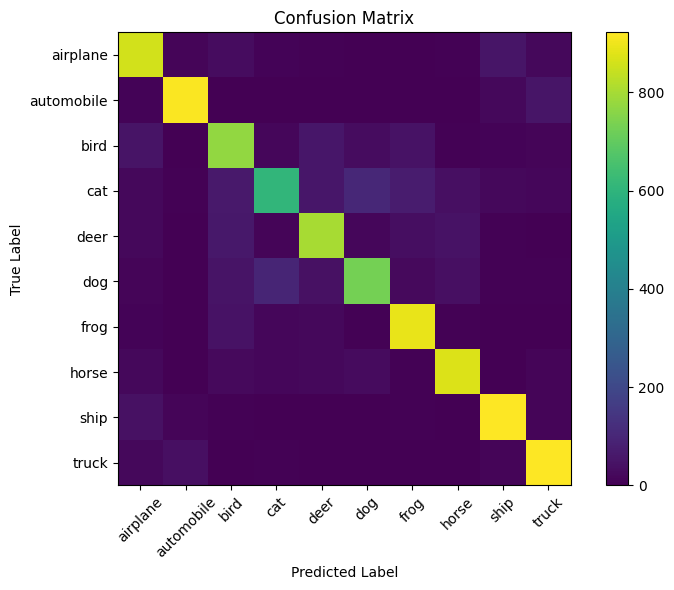

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()


The confusion matrix shows strong diagonal dominance, indicating correct classification for most classes. Misclassifications primarily occur between visually similar categories such as cats and dogs or automobiles and trucks, which is expected for the CIFAR-10 dataset. Overall, the matrix confirms that the model generalizes well across classes.

## **Correct and Incorrect Predictions: Qualitative Evaluation**

**Purpose**:

While accuracy and confusion matrices provide quantitative performance metrics, visualizing correctly and incorrectly classified examples offers qualitative insight into the model’s behavior and common failure modes.

Collect Correct and Incorrect Predictions

In [21]:
model.eval()

correct_samples = []
incorrect_samples = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(images.size(0)):
            image = images[i].cpu()
            true_label = labels[i].item()
            pred_label = preds[i].item()

            if true_label == pred_label and len(correct_samples) < 5:
                correct_samples.append((image, true_label, pred_label))

            elif true_label != pred_label and len(incorrect_samples) < 5:
                incorrect_samples.append((image, true_label, pred_label))

        if len(correct_samples) >= 5 and len(incorrect_samples) >= 5:
            break


Visualize Correct Predictions

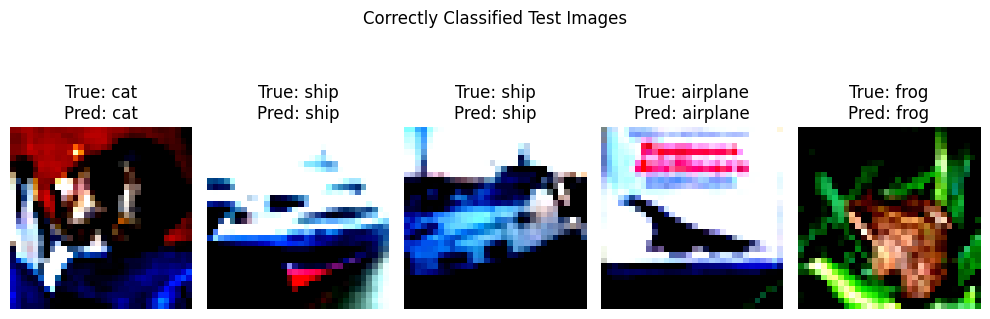

In [22]:
plt.figure(figsize=(10, 4))

for i, (image, true_label, pred_label) in enumerate(correct_samples):
    plt.subplot(1, 5, i + 1)
    img = image.permute(1, 2, 0)
    plt.imshow(img)
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}")
    plt.axis("off")

plt.suptitle("Correctly Classified Test Images")
plt.tight_layout()
plt.show()


Figure presents examples of correctly classified CIFAR-10 test images. These samples demonstrate the model’s ability to identify distinctive visual features across multiple object categories, supporting the quantitative performance observed in the accuracy metrics and confusion matrix.

Visualize Incorrect Predictions

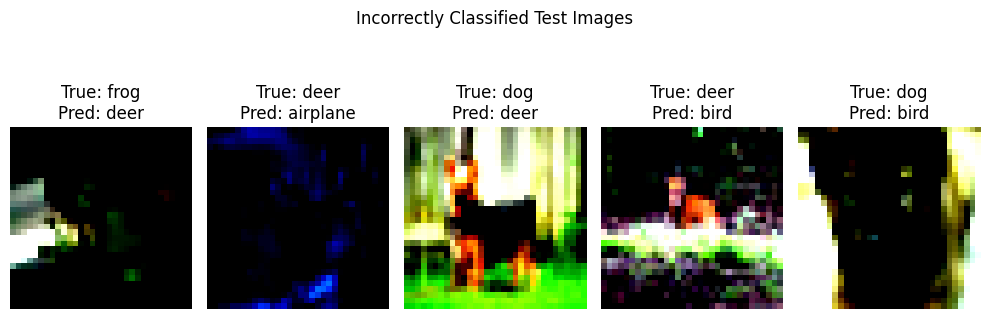

In [23]:
plt.figure(figsize=(10, 4))

for i, (image, true_label, pred_label) in enumerate(incorrect_samples):
    plt.subplot(1, 5, i + 1)
    img = image.permute(1, 2, 0)
    plt.imshow(img)
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}")
    plt.axis("off")

plt.suptitle("Incorrectly Classified Test Images")
plt.tight_layout()
plt.show()
